In [ ]:
import os
import cv2
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm

from sklearn.utils import shuffle
from sklearn.metrics import classification_report, accuracy_score, RocCurveDisplay, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelBinarizer,LabelEncoder, label_binarize
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.svm import LinearSVC

from tensorflow import keras 
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Model, Sequential, save_model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D
from keras.optimizers import Adam
from keras.utils import to_categorical
from keras.applications import DenseNet121
from sklearn.metrics import roc_curve, auc

from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

from keras.backend import clear_session
import gc

# Compréhension des données

In [ ]:
# Charger les fichiers CSV des étiquettes
train_labels = pd.read_csv(r"C:\Users\Lenovo\Downloads\RAF_DB\train_labels.csv")
test_labels = pd.read_csv(r"C:\Users\Lenovo\Downloads\RAF_DB\test_labels.csv")

# Afficher les premières lignes des étiquettes d'entraînement pour vérifier la structure
print(train_labels.head())

classes = ['surprise', 'fear', 'disgust', 'happy', 'sad', 'angry', 'neutral']


label_map = {label: (idx+1) for idx, label in enumerate(classes)}

print(label_map)

                     image  label
0  train_00001_aligned.jpg      5
1  train_00002_aligned.jpg      5
2  train_00003_aligned.jpg      4
3  train_00004_aligned.jpg      4
4  train_00005_aligned.jpg      5
{'surprise': 1, 'fear': 2, 'disgust': 3, 'happy': 4, 'sad': 5, 'angry': 6, 'neutral': 7}


In [ ]:
# Fonction pour charger les images et les étiquettes depuis le répertoire
def load_data(dataset_dir, label_map):
    images = []
    labels = []
    
    for label, idx in tqdm(label_map.items()):
        folder_path = os.path.join(dataset_dir, str(idx))  
        for filename in os.listdir(folder_path):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img_rgb)
            labels.append(idx)
    
    return np.array(images), np.array(labels)

# Charger les ensembles de données d'entraînement et de test
train_images, train_labels = load_data(r"C:\Users\Lenovo\Downloads\RAF_DB\DATASET\train", label_map)
test_images, test_labels = load_data(r"C:\Users\Lenovo\Downloads\RAF_DB\DATASET\test", label_map)
print(train_images.shape)
print(test_images.shape)

100%|██████████| 7/7 [00:49<00:00,  7.02s/it]

(12271, 100, 100, 3)
(3068, 100, 100, 3)


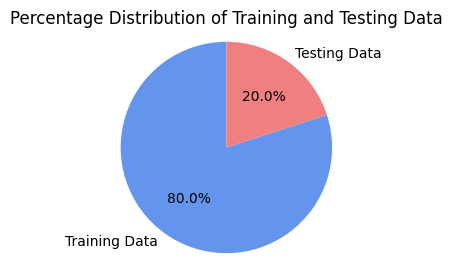

In [ ]:
# Calculer le nombre total d'images
total_images = len(train_images) + len(test_images)

# Calculer les pourcentages
train_percentage = (len(train_images) / total_images) * 100
test_percentage = (len(test_images) / total_images) * 100

# Données pour le diagramme circulaire
labels = ['Training Data', 'Testing Data']
sizes = [train_percentage, test_percentage]
colors = ['cornflowerblue', 'lightcoral']

# Tracer le diagramme circulaire
plt.figure(figsize=(3, 3))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Percentage Distribution of Training and Testing Data')
plt.axis('equal')  
plt.show()

train_label_counts  Counter({4: 4772, 7: 2524, 5: 1982, 1: 1290, 3: 717, 6: 705, 2: 281})
test_counts [329, 74, 160, 1185, 478, 162, 680]


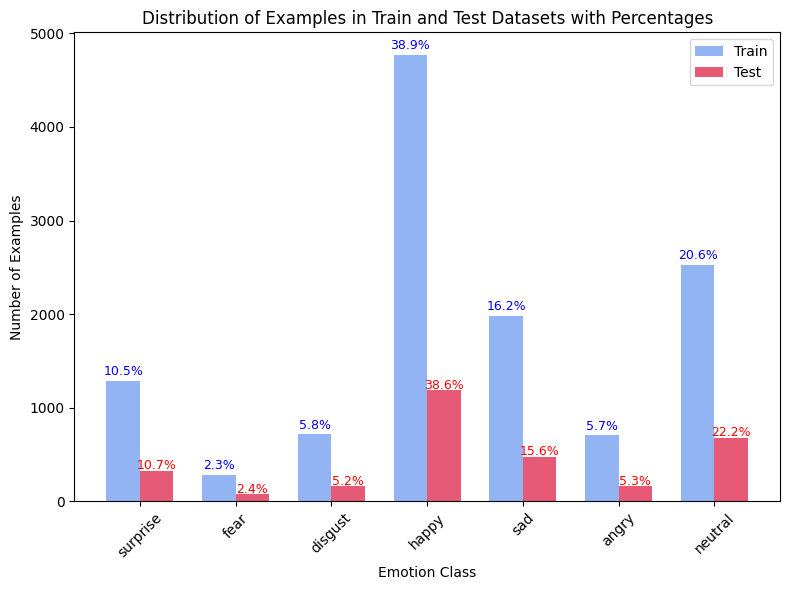

In [ ]:
# Compter la distribution des classes dans les ensembles de données d'entraînement et de test
train_label_counts = Counter(train_labels)
test_label_counts = Counter(test_labels)
print('train_label_counts ',train_label_counts)
# Convertir en listes triées pour le tracé
train_classes = sorted(train_label_counts.keys())
train_counts = [train_label_counts[cls] for cls in train_classes]

test_classes = sorted(test_label_counts.keys())
test_counts = [test_label_counts[cls] for cls in test_classes]
print('test_counts',test_counts)
# Calculer le nombre total d'exemples dans les ensembles de données d'entraînement et de test
total_train = sum(train_counts)
total_test = sum(test_counts)

# Calculer les pourcentages pour les ensembles de données d'entraînement et de test
train_percentages = [(count / total_train) * 100 for count in train_counts]
test_percentages = [(count / total_test) * 100 for count in test_counts]

# Tracer la distribution avec les pourcentages
plt.figure(figsize=(8, 6))
x = range(len(classes))
bar_width = 0.35

plt.bar(x, train_counts, width=bar_width, label="Train", alpha=0.7, color="cornflowerblue")
plt.bar([p + bar_width for p in x], test_counts, width=bar_width, label="Test", alpha=0.7, color="crimson")

# Annoter les pourcentages sur les barres
for i, (train_count, test_count) in enumerate(zip(train_counts, test_counts)):
    plt.text(i, train_count + 0.005 * total_train, f"{train_percentages[i]:.1f}%", ha='center', color="blue", fontsize=9)
    plt.text(i + bar_width, test_count + 0.005 * total_test, f"{test_percentages[i]:.1f}%", ha='center', color="red", fontsize=9)

# Ajouter des étiquettes et un titre
plt.xticks([p + bar_width / 2 for p in x], classes, rotation=45)
plt.xlabel("Emotion Class")
plt.ylabel("Number of Examples")
plt.title("Distribution of Examples in Train and Test Datasets with Percentages")
plt.legend()
plt.tight_layout()

# Afficher le graphique
plt.show()

Le jeu de données montre un déséquilibre clair entre les classes, avec la classe "Happy" (Heureux) étant la classe dominante (39,9%), et les classes "Fear" (Peur) et "Angry" (Colère) étant sous-représentées (2,3% et 5,7%). Ce déséquilibre pourrait amener le modèle à favoriser la classe majoritaire, entraînant ainsi une mauvaise performance pour les classes minoritaires. La distribution est cohérente entre les ensembles d'entraînement et de test, mais des techniques telles que le pondération des classes, le suréchantillonnage ou l'augmentation de données sont nécessaires pour traiter ce déséquilibre et améliorer la performance du modèle.

In [ ]:
# Combiner les ensembles de données d'entraînement et de test dans les mêmes variables
X_train = np.concatenate([train_images, test_images], axis=0)
Y_train = np.concatenate([train_labels, test_labels], axis=0)

# Afficher les dimensions pour confirmer
print(X_train.shape)
print(Y_train.shape)

(15339, 100, 100, 3)
(15339,)


Pour simplifier les étapes de prétraitement, les ensembles de données d'entraînement et de test sont fusionnés en un seul jeu de données. Cela est réalisé en concaténant les images (train_images et test_images) et leurs étiquettes correspondantes (train_labels et test_labels) le long du premier axe, créant ainsi des variables unifiées pour un traitement ultérieur.

Ce jeu de données combiné permettra d'effectuer des étapes unifiées d'augmentation de données et de prétraitement avant de le diviser à nouveau pour l'entraînement et l'évaluation du modèle. Les dimensions des tableaux résultants sont affichées pour vérifier la fusion.

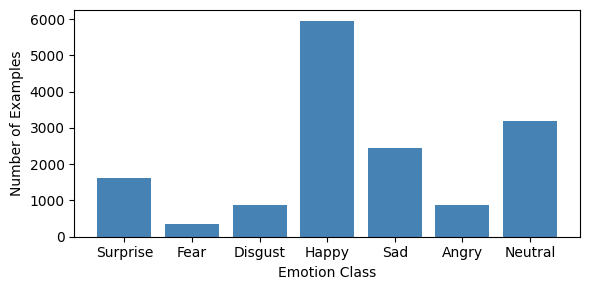

In [ ]:
# Compter la distribution des classes dans l'ensemble de données d'entraînement rééchantillonné
train_label_counts_resampled = Counter(Y_train)
    
# Convertir en listes triées pour le tracé
train_classes_resampled = sorted(train_label_counts_resampled.keys())
train_counts_resampled = [train_label_counts_resampled[cls] for cls in train_classes_resampled]
# Tracer la distribution
plt.figure(figsize=(6, 3))
x_labels = ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Angry', 'Neutral']
    
# Diagramme à barres pour la distribution rééchantillonnée
plt.bar(x_labels, train_counts_resampled, color="steelblue")
    
# Ajouter des étiquettes et un titre
plt.xlabel("Emotion Class")
plt.ylabel("Number of Examples")
plt.title('')
plt.tight_layout()
    
# Afficher le graphique
plt.show()

In [ ]:
# Mélanger X_train et Y_train
X_train, Y_train = shuffle(X_train, Y_train, random_state=42)

# Afficher les dimensions pour confirmer que les données sont mélangées
print(X_train.shape)
print(Y_train.shape)

(15339, 100, 100, 3)
(15339,)


Pour garantir que les données d'entraînement sont présentées au modèle dans un ordre aléatoire, nous mélangeons les ensembles de données X_train et Y_train en utilisant un état aléatoire fixe pour assurer la reproductibilité. Cette étape aide à empêcher le modèle d'apprendre des motifs non désirés dus à l'ordre des données, améliorant ainsi le processus global d'entraînement.

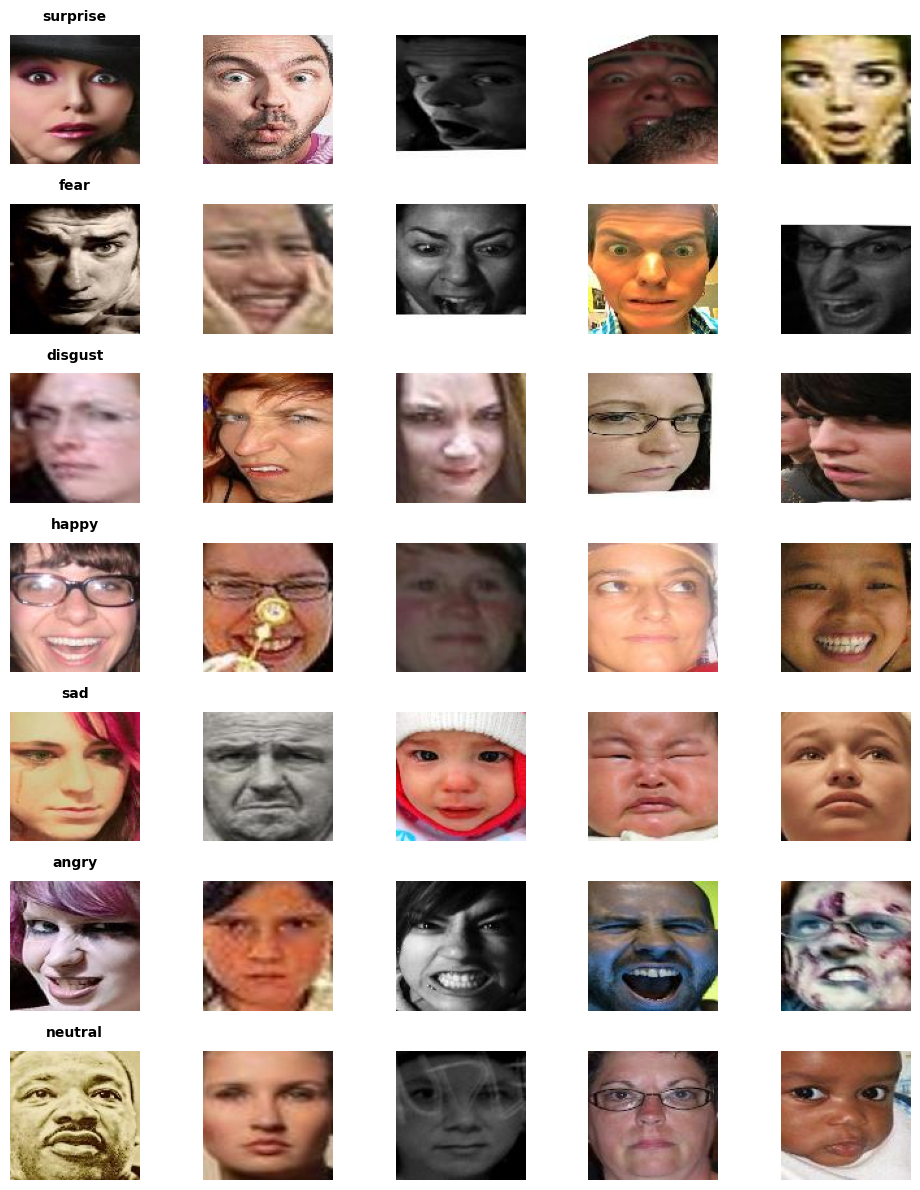

In [ ]:
def show_examples(train_images, train_labels, labels, num_examples=5):
    num_classes = len(classes)
    fig, axs = plt.subplots(num_classes, num_examples, figsize=(10, 12))
    
    for i, class_name in enumerate(classes):
        class_indices = [idx for idx, label in enumerate(train_labels) if label == i+1]
        selected_indices = np.random.choice(class_indices, num_examples, replace=False)
        axs[i, 0].set_title(class_name, fontsize=10, pad=10, fontweight='bold')
        # Afficher les images aléatoires pour la classe actuelle
        for j, idx in enumerate(selected_indices):
            img = train_images[idx]
            axs[i, j].imshow(img)
            axs[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()

# Afficher des images d'exemple pour chaque classe
show_examples(X_train, Y_train, classes)

In [ ]:
# Tailles d'images les plus fréquentes :
train_data_shapes = []
for img in X_train:
  train_data_shapes.append(img.shape)
# Compter les occurrences pour chaque taille
shape_counts = {}
for shape in train_data_shapes:
  if shape not in shape_counts:
    shape_counts[shape] = 0
  shape_counts[shape] += 1
# Trier les formes par fréquence
sorted_shapes = sorted(shape_counts.items(), key=lambda x: x[1], reverse=True)
# Afficher la taille la plus fréquente
print("Most frequent Train images shapes:")
for shape, count in sorted_shapes[:3]:
  print(f"- {shape}: {count}")

Most frequent Train images shapes:
- (100, 100, 3): 15339


La forme d'image la plus fréquente dans l'ensemble de données d'entraînement est (100, 100, 3), avec 12 271 images dans cette résolution. Étant donné que la majorité des images du jeu de données ont déjà une taille cohérente de 100x100 pixels avec trois canaux de couleur (RGB), il n'est pas nécessaire de redimensionner les images. En maintenant leurs dimensions d'origine, on évite des frais de calcul inutiles et on préserve la qualité et les caractéristiques des données. Cette cohérence simplifie le prétraitement et garantit que le modèle reçoit des entrées dans leur résolution native, ce qui peut conduire à une meilleure extraction de caractéristiques et à une meilleure performance du modèle.

# préparation des données

### 1. Suréchantillonnage
Dans ce cahier, nous abordons le déséquilibre des classes en appliquant des techniques de suréchantillonnage. Tout d'abord, nous réduisons la taille de la classe 'happy' à un nombre cible en utilisant un échantillonnage aléatoire. Ensuite, nous augmentons les classes ayant moins d'exemples en générant des images supplémentaires grâce à des techniques d'augmentation de données telles que la rotation, la translation, le zoom et le retournement horizontal. Cela garantit une distribution équilibrée des classes, rendant l'entraînement du modèle plus robuste et améliorant ses performances sur les classes sous-représentées. La distribution finale du jeu de données est visualisée après les processus de réduction et d'augmentation pour confirmer l'efficacité de ces techniques.

In [ ]:
# Fonction pour tracer la distribution des classes
def plot_class_distribution(y, title):
    # Compter la distribution des classes dans l'ensemble de données d'entraînement rééchantillonné
    train_label_counts_resampled = Counter(y)
    
    # Convertir en listes triées pour le tracé
    train_classes_resampled = sorted(train_label_counts_resampled.keys())
    train_counts_resampled = [train_label_counts_resampled[cls] for cls in train_classes_resampled]
    
    #  Tracer la distribution
    plt.figure(figsize=(6, 3))
    x_labels = ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Angry', 'Neutral']
    
    # Diagramme à barres pour la distribution rééchantillonnée
    plt.bar(x_labels, train_counts_resampled, color="steelblue")
    
    # Ajouter des étiquettes et un titre
    plt.xlabel("Emotion Class")
    plt.ylabel("Number of Examples")
    plt.title(title)
    plt.tight_layout()
    
    # Afficher le graphique
    plt.show()

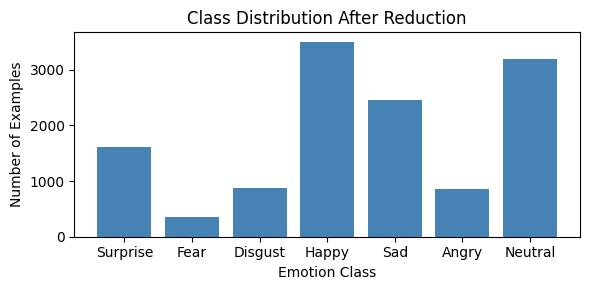

In [ ]:
# Fonction pour réduire la taille d'une classe spécifique dans le jeu de données
def reduce_class(X, y, target_class, target_size):
    # Séparer la classe cible
    class_indices = np.where(y == target_class)[0]
    non_class_indices = np.where(y != target_class)[0]
    
    # Échantillonner aléatoirement la classe cible à la taille souhaitée
    reduced_class_indices = np.random.choice(class_indices, target_size, replace=False)
    
    # Combiner la classe réduite avec les autres classes
    final_indices = np.concatenate([reduced_class_indices, non_class_indices])
    X_reduced = X[final_indices]
    y_reduced = y[final_indices]
    
    return X_reduced, y_reduced

target_class = 4  # La classe 'happy'
target_size = 3500
X_train_reduced, y_train_reduced = reduce_class(X_train, Y_train, target_class, target_size)
# Tracer la nouvelle distribution après réduction
plot_class_distribution(y_train_reduced, "Class Distribution After Reduction")

Classe 1: 1619 échantillons augmentés avec 1881 échantillons.
Classe 2: 355 échantillons augmentés avec 3145 échantillons.
Classe 3: 877 échantillons augmentés avec 2623 échantillons.
Classe 5: 2460 échantillons augmentés avec 1040 échantillons.
Classe 6: 867 échantillons augmentés avec 2633 échantillons.
Classe 7: 3204 échantillons augmentés avec 296 échantillons.


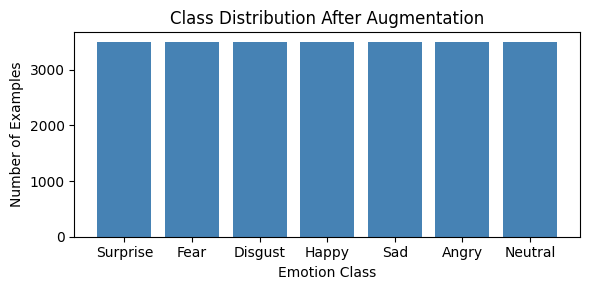

In [ ]:
def augment_classes(images, labels, target_counts):
    # Initialisation de la génération d'images augmentées
    datagen = ImageDataGenerator(
        rotation_range=10,             
        width_shift_range=0.1,         
        height_shift_range=0.1,  
        zoom_range=0.1,
        vertical_flip=False,               
        horizontal_flip=True, 
        channel_shift_range=50.0,
        fill_mode='nearest'
    )

    augmented_images = images.copy()  # Nous copions les images pour conserver les originales
    augmented_labels = labels.copy()  # Idem pour les labels

    # Pour chaque classe, nous augmentons le nombre d'échantillons
    for target_class, target_count in target_counts.items():
        # Filtrage des images et labels pour la classe cible
        class_images = images[labels == target_class]
        class_labels = labels[labels == target_class]
        # Calcul du nombre d'échantillons à générer
        augment_count = target_count - len(class_images)

        if augment_count > 0:
            print(f'Classe {target_class}: {len(class_images)} échantillons augmentés avec {augment_count} échantillons.')

            # Création d'un itérateur pour la classe cible
            class_images_augmented = []
            class_labels_augmented = []

            # Appliquer l'augmentation de manière itérative
            for batch in datagen.flow(class_images, batch_size=1, seed=42):
                aug_image = batch[0].astype(np.uint8)
                class_images_augmented.append(aug_image)
                class_labels_augmented.append(target_class)
                
                # Arrêter quand le nombre souhaité d'images augmentées est atteint
                if len(class_images_augmented) >= augment_count:
                    break
            
            # Ajouter les images augmentées au jeu de données original
            augmented_images = np.vstack((augmented_images, np.array(class_images_augmented)))
            augmented_labels = np.hstack((augmented_labels, np.array(class_labels_augmented)))

    return augmented_images, augmented_labels

# Exemple d'utilisation
target_counts = {1: 3500, 2: 3500, 3: 3500, 5: 3500, 6: 3500, 7: 3500}  # Comptes cibles pour chaque classe
X_train_augmented, y_train_augmented = augment_classes(X_train_reduced, y_train_reduced, target_counts)

# Visualiser la distribution des classes après l'augmentation
plot_class_distribution(y_train_augmented, "Class Distribution After Augmentation")

### 1. Séparation

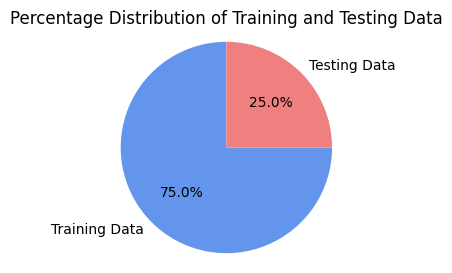

In [ ]:
# Diviser les données en ensembles d'entraînement et de test (75% pour l'entraînement, 25% pour le test)
X_train, X_test, Y_train, Y_test = train_test_split(X_train_augmented, 
                                                    y_train_augmented, 
                                                    test_size=0.25, 
                                                    shuffle=True,
                                                    random_state=42)

# Calculer le nombre total d'images
total_images = len(X_train) + len(X_test)

# Calculer les pourcentages
train_percentage = (len(X_train) / total_images) * 100
test_percentage = (len(X_test) / total_images) * 100

# Données pour le diagramme circulaire
labels = ['Training Data', 'Testing Data']
sizes = [train_percentage, test_percentage]
colors = ['cornflowerblue', 'lightcoral']

# Tracer le diagramme circulaire
plt.figure(figsize=(3, 3))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Percentage Distribution of Training and Testing Data')
plt.axis('equal')  
plt.show()

Le jeu de données est divisé en ensembles d'entraînement et de test, avec 80 % alloués à l'entraînement et 20 % au test, en utilisant la fonction train_test_split. Cette séparation est cruciale pour évaluer la capacité de généralisation du modèle sur des données non vues.

### 2. Normaliser les images

In [ ]:
def normalize_images(images):
    # Normaliser les valeurs des pixels dans l'intervalle [0, 1]
    return images / 255.0

train_images_normalized = normalize_images(X_train)
test_images_normalized = normalize_images(X_test)

Pour standardiser les valeurs des pixels et garantir une entrée cohérente pour le modèle, les données des images sont normalisées en échelonnant les valeurs des pixels dans l'intervalle [0, 1]. Cela est réalisé en divisant les valeurs des pixels par 255, la valeur maximale des pixels pour une image en 8 bits. Les images d'entraînement et de test sont normalisées selon cette méthode pour faciliter une meilleure performance du modèle et une convergence plus rapide lors de l'entraînement.

### 3. Redimensionner les images

In [ ]:
def reshape_images_for_CNN(images):
    # Le CNN nécessite que les images aient la forme (hauteur, largeur, canaux)
    return images.reshape((images.shape[0], 100, 100, 3))

# Redimensionner les images pour le CNN
train_images_CNNreshaped = reshape_images_for_CNN(train_images_normalized)
test_images_CNNreshaped = reshape_images_for_CNN(test_images_normalized)


Dans cette étape, les images sont redimensionnées pour répondre aux exigences d'entrée des Réseaux de Neurones Convolutifs (CNN).

Les modèles CNN nécessitent que les images d'entrée conservent leur structure spatiale, avec des dimensions correspondant à la hauteur, la largeur et le nombre de canaux de couleur (par exemple, RGB). Par conséquent, chaque image est redimensionnée en un format 3D (100, 100, 3), ce qui préserve les informations spatiales et colorées essentielles.

Ce redimensionnement garantit que les images sont dans le bon format pour être traitées efficacement par le CNN lors de l'entraînement et des tests

### 4. Convertir les labels en catégoriels


In [ ]:
# Convertir les labels en catégoriels pour le CNN
Y_train_cat = to_categorical(Y_train - 1, num_classes=len(classes))
Y_test_cat = to_categorical(Y_test - 1, num_classes=len(classes))

Les labels sont convertis en format one-hot encodé, en les ajustant par soustraction de 1 pour correspondre à la plage d'index. Cette conversion est cruciale pour des modèles comme les CNN, qui nécessitent que les labels cibles soient dans un format catégoriel (sous forme de vecteurs) afin de calculer la fonction de perte lors de l'entraînement et de l'évaluation. Le nombre de catégories est défini par le nombre total de classes dans le jeu de données.

### 5. Augmentation de données pour le CNN

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,             
    width_shift_range=0.1,         
    height_shift_range=0.1,  
    vertical_flip=False,               
    horizontal_flip=True, 
    fill_mode='nearest'
)

# Créer le générateur pour l'entraînement
train_generator = datagen.flow(train_images_CNNreshaped, Y_train_cat, batch_size=64)

Pour améliorer la capacité du modèle à se généraliser, l'augmentation de données est appliquée à l'aide d'ImageDataGenerator. Cela implique l'application de transformations aléatoires, ce qui aide le modèle à devenir plus robuste face aux variations dans les images d'entrée

### le modèle CNN

In [ ]:
# Définir le modèle CNN
cnn_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(test_images_CNNreshaped[0].shape)),
    MaxPooling2D((2, 2)),
    
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Conv2D(512, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(len(classes), activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 98, 98, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 49, 49, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 47, 47, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 23, 23, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 21, 21, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 10, 10, 128)      0

In [ ]:
# Entraîner le modèle CNN
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=10, min_delta=0.0001, verbose=1) 
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1)  
checkpoint = ModelCheckpoint(filepath='best_CNNModel.keras', monitor='val_accuracy', save_best_only=True, verbose=1) 

CNN_History = cnn_model.fit(
    train_generator,
    epochs=60, 
    batch_size = 32,
    validation_data=(test_images_CNNreshaped, Y_test_cat), 
    callbacks=[reduce_lr, early_stop, checkpoint]
)

Epoch 1/60
288/288 [==============================] - ETA: 0s - loss: 1.8510 - accuracy: 0.2414
Epoch 1: val_accuracy improved from -inf to 0.30416, saving model to best_CNNModel.keras
288/288 [==============================] - 214s 734ms/step - loss: 1.8510 - accuracy: 0.2414 - val_loss: 1.7290 - val_accuracy: 0.3042 - lr: 0.0010
Epoch 2/60
288/288 [==============================] - ETA: 0s - loss: 1.6543 - accuracy: 0.3565
Epoch 2: val_accuracy improved from 0.30416 to 0.48767, saving model to best_CNNModel.keras
288/288 [==============================] - 202s 699ms/step - loss: 1.6543 - accuracy: 0.3565 - val_loss: 1.3800 - val_accuracy: 0.4877 - lr: 0.0010
Epoch 3/60
288/288 [==============================] - ETA: 0s - loss: 1.4527 - accuracy: 0.4556
Epoch 3: val_accuracy improved from 0.48767 to 0.53959, saving model to best_CNNModel.keras
288/288 [==============================] - 201s 696ms/step - loss: 1.4527 - accuracy: 0.4556 - val_loss: 1.2308 - val_accuracy: 0.5396 - lr: 0.

In [27]:
CNN_History.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy', 'lr'])

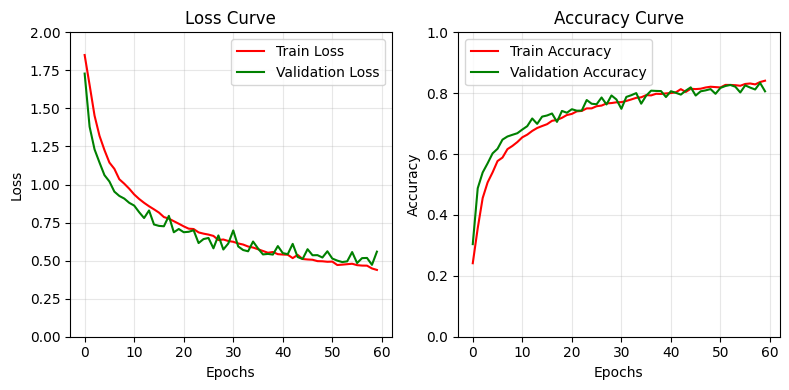

In [28]:
train_loss = CNN_History.history['loss']
val_loss = CNN_History.history['val_loss']
train_accuracy = CNN_History.history['accuracy']
val_accuracy = CNN_History.history['val_accuracy']

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].plot(train_loss, label='Train Loss', color='red')
ax[0].plot(val_loss, label='Validation Loss', color='green')
ax[0].set_title('Loss Curve')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].set_ylim([0, 2])
ax[0].grid(alpha=0.3)

ax[1].plot(train_accuracy, label='Train Accuracy', color='red')
ax[1].plot(val_accuracy, label='Validation Accuracy', color='green')
ax[1].set_title('Accuracy Curve')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].set_ylim([0, 1])
ax[1].grid(alpha=0.3)

# Ajuster l'espacement entre les sous-graphes

plt.tight_layout()
plt.show()

In [ ]:
train_CNNresult = cnn_model.evaluate(train_images_CNNreshaped, Y_train_cat)
test_CNNresult = cnn_model.evaluate(test_images_CNNreshaped, Y_test_cat)

# Évaluer le modèle CNN
print("Train Loss: {:.2f}%".format(train_CNNresult[0] * 100))
print("Train Accuracy: {:.2f}%".format(train_CNNresult[1] * 100))

print("\nTest Loss: {:.2f}%".format(test_CNNresult[0] * 100))
print("Test Accuracy: {:.2f}%".format(test_CNNresult[1] * 100))

192/192 [==============================] - 16s 84ms/step - loss: 0.5589 - accuracy: 0.8062
Train Loss: 32.40%
Train Accuracy: 88.49%

Test Loss: 55.89%
Test Accuracy: 80.62%


In [ ]:
# Prédire sur l'ensemble de test
y_predCNN_prob = cnn_model.predict(test_images_CNNreshaped)  # Prédire les probabilités
y_predCNN = np.argmax(y_predCNN_prob, axis=1)   # Convertir en labels de classes
y_true = np.argmax(Y_test_cat, axis=1)   # Convertir les labels one-hot encodés en indices de classes

# Générer le rapport de classification
print("Classification Report:")
print(classification_report(y_true, y_predCNN, target_names=classes))

192/192 [==============================] - 16s 77ms/step
Classification Report:
              precision    recall  f1-score   support

    surprise       0.94      0.76      0.84       870
        fear       0.97      0.84      0.90       840
     disgust       0.78      0.76      0.77       910
       happy       0.88      0.84      0.86       887
         sad       0.67      0.81      0.73       865
       angry       0.84      0.90      0.87       859
     neutral       0.68      0.75      0.71       894

    accuracy                           0.81      6125
   macro avg       0.82      0.81      0.81      6125
weighted avg       0.82      0.81      0.81      6125



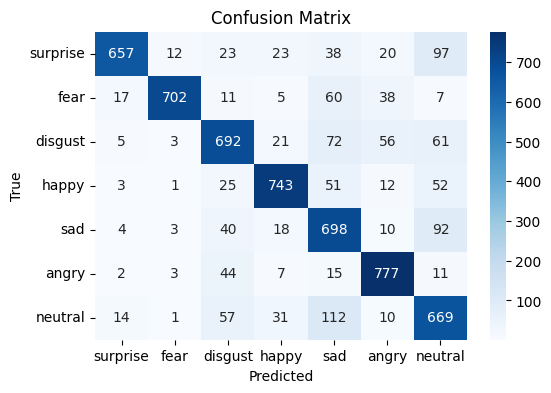

In [ ]:
# Calculer la matrice de confusion
conf_matrix = confusion_matrix(y_true, y_predCNN)

# Tracer la matrice de confusion
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

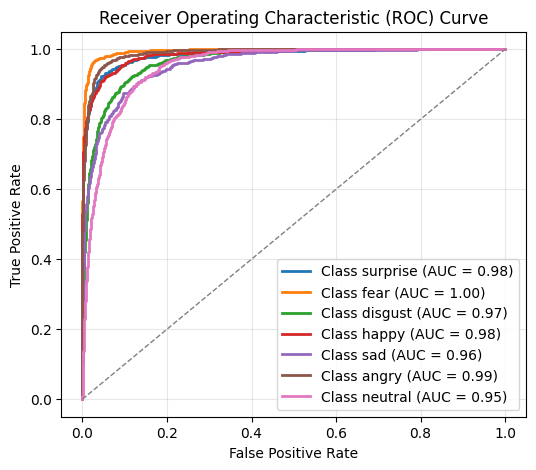

In [ ]:
# Binariser les labels réels pour le calcul de la ROC multi-classes
y_true_bin = label_binarize(y_true, classes=list(range(len(classes))))

# Initialisation des FPR, TPR, et AUC pour chaque classe
fpr = {}
tpr = {}
roc_auc = {}

# Calcul des courbes ROC et de l'AUC pour chaque classe
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_predCNN_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Tracer toutes les courbes ROC
plt.figure(figsize=(6, 5))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

# Ligne de référence pour une prédiction aléatoire
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

# Personnalisation du graphique

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

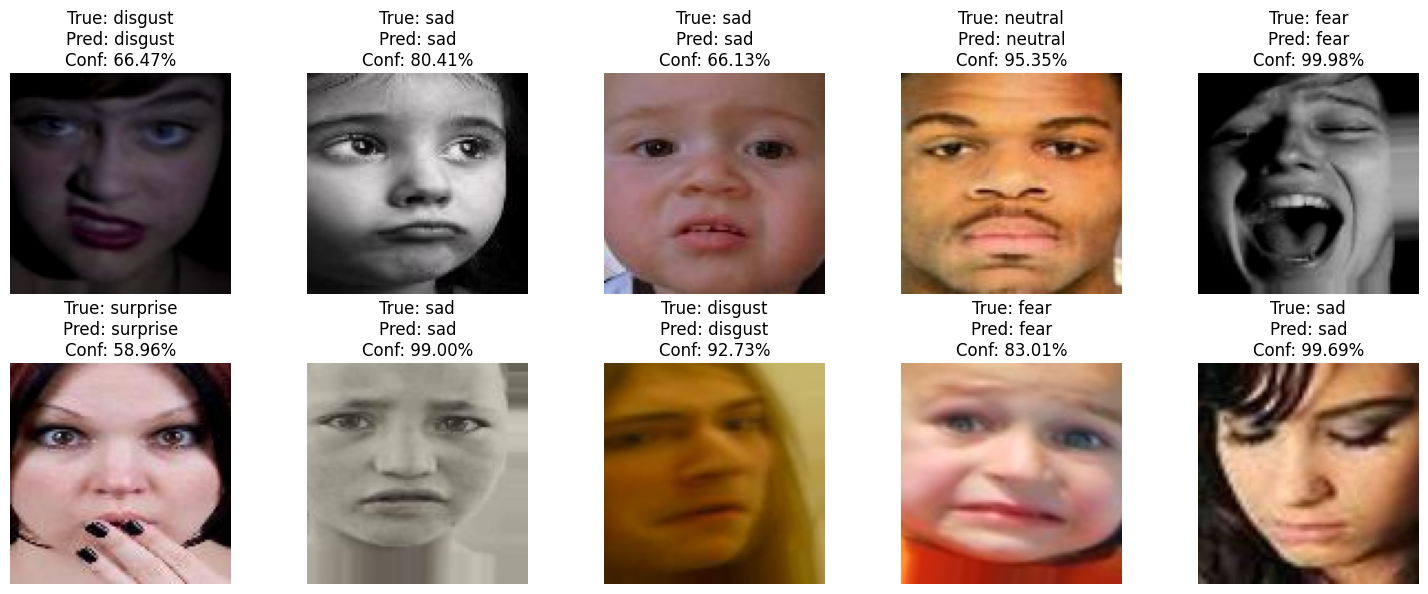

In [ ]:
random_indices = np.random.choice(len(test_images_CNNreshaped), 10, replace=False)

fig, ax = plt.subplots(2, 5, figsize=(15, 6))

for i, idx in enumerate(random_indices):
    image = test_images_CNNreshaped[idx]
    true_class = classes[Y_test[idx] - 1]  
    pred_class = classes[y_predCNN[idx]]  
    confidence = np.max(y_predCNN_prob[idx]) * 100   
    
    # Tracer
    ax[i // 5, i % 5].imshow(image)
    ax[i // 5, i % 5].axis('off')  
    ax[i // 5, i % 5].set_title(f'True: {true_class}\nPred: {pred_class}\nConf: {confidence:.2f}%')

plt.tight_layout()
plt.show()